### Plot ROMS and CICE grids for comparison
To make the CICE grid:
```
python cice_c_to_b.py /pscratch/sd/d/dylan617/roms/beaufort_inputs/whats_up_with_grid_files4dylan/KakAKgrd_shelf_big010_smooth006_thin_sponge.nc 
```
To inject mask into new grid:
```
python replace_cice_landmask_with_roms.py new_cice.kmt.nc /pscratch/sd/d/dylan617/roms/beaufort_inputs/whats_up_with_grid_files4dylan/KakAKgrd_shelf_big010_smooth006_thin_sponge.nc
```


In [1]:
#Packages 
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
import xarray as xr
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])
from matplotlib import ticker
crs = ccrs.PlateCarree()
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature

rpath = '/global/u2/d/dylan617/repos/notebooks/txla_roms/natural_earth/ne_10m_rivers_north_america.shp'
rivers = ShapelyFeature(Reader(rpath).geometries(),
                        ccrs.PlateCarree(), facecolor='none', edgecolor = 'blue')

In [2]:
# ROMS 
path = '/pscratch/sd/d/dylan617/roms/beaufort_inputs/whats_up_with_grid_files4dylan/KakAKgrd_shelf_big010_smooth006_thin_sponge.nc'
dsr = xr.open_dataset(path)

# CICE
path = '/pscratch/sd/d/dylan617/metroms/tools/new_cice.grid.nc'
dsc = xr.open_dataset(path)
dsc

<xarray.Dataset> Size: 5MB
Dimensions:  (xi_t: 608, xi_u: 608, eta_t: 206, eta_u: 206)
Coordinates:
  * xi_t     (xi_t) float32 2kB 0.0 1.0 2.0 3.0 4.0 ... 604.0 605.0 606.0 607.0
  * xi_u     (xi_u) float32 2kB 0.0 1.0 2.0 3.0 4.0 ... 604.0 605.0 606.0 607.0
  * eta_t    (eta_t) float32 824B 0.0 1.0 2.0 3.0 ... 202.0 203.0 204.0 205.0
  * eta_u    (eta_u) float32 824B 0.0 1.0 2.0 3.0 ... 202.0 203.0 204.0 205.0
Data variables:
    ulat     (eta_u, xi_u) float32 501kB ...
    ulon     (eta_u, xi_u) float32 501kB ...
    angle    (eta_u, xi_u) float32 501kB ...
    HTN      (eta_u, xi_u) float32 501kB ...
    HTE      (eta_u, xi_u) float32 501kB ...
    dxt      (eta_u, xi_u) float32 501kB ...
    dyt      (eta_u, xi_u) float32 501kB ...
    dxu      (eta_u, xi_u) float32 501kB ...
    dyu      (eta_u, xi_u) float32 501kB ...
Attributes:
    type:     cice grid information
    grid:     on T points

### Plot every 5th grid point 

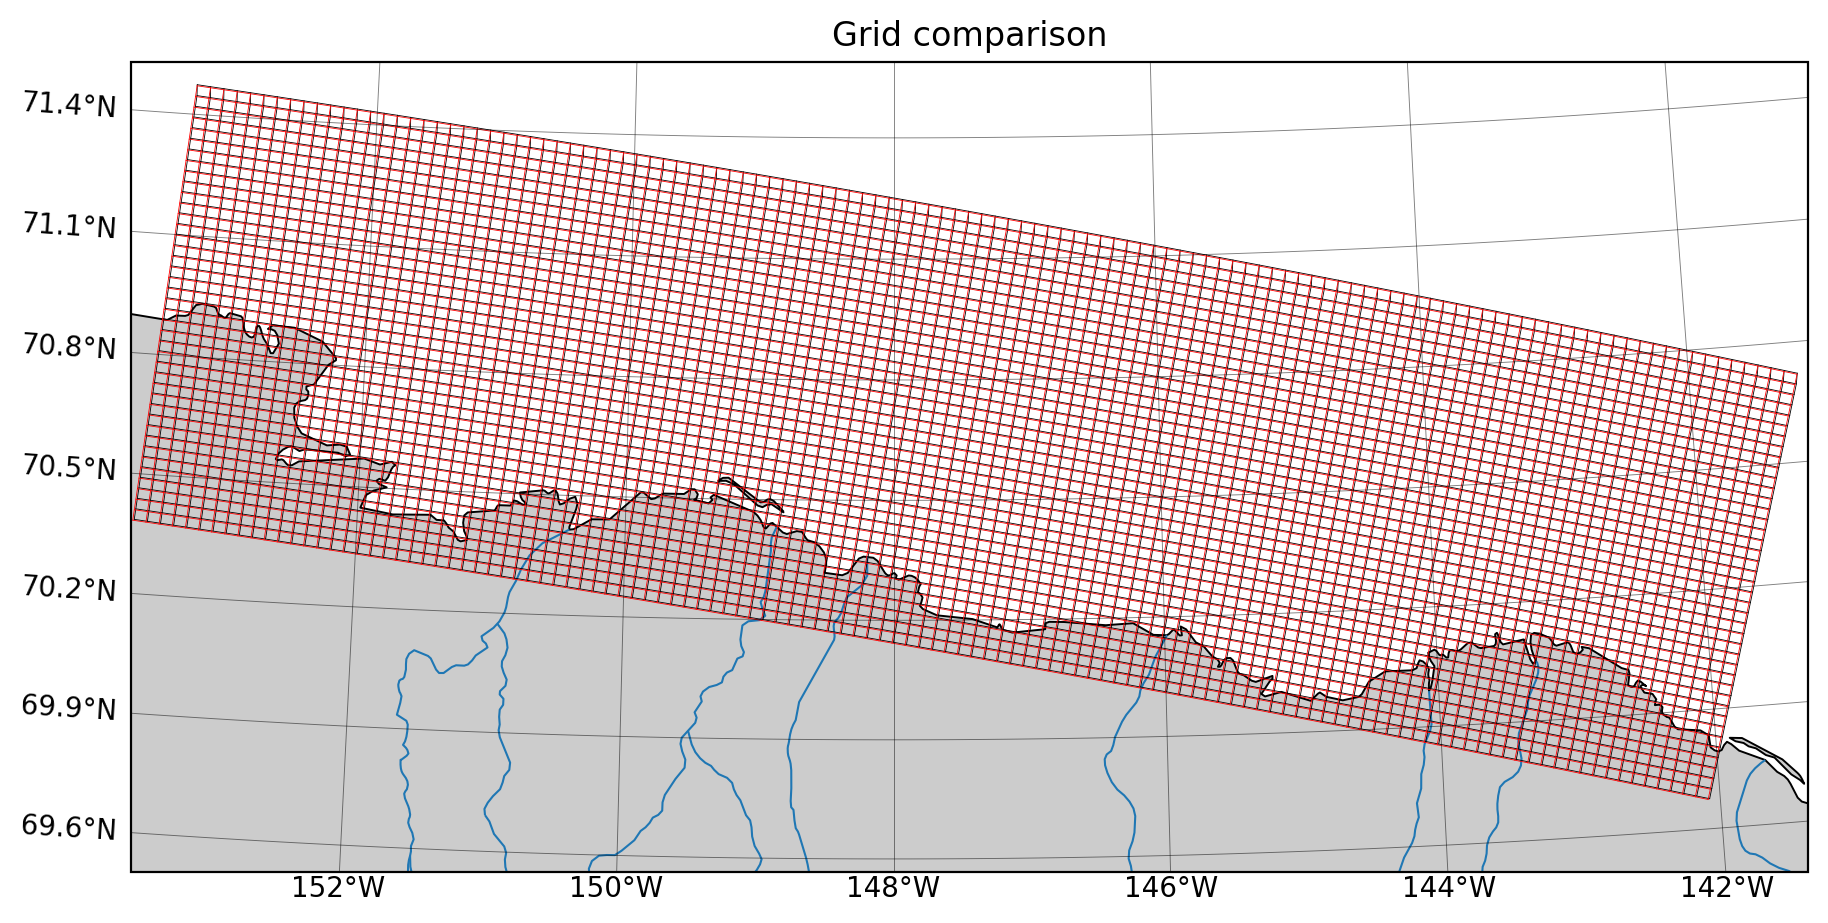

In [19]:
crs = ccrs.LambertConformal(
    central_longitude=-148,
    central_latitude=70.5,
    standard_parallels=(30, 60)  # usually two standard parallels
)

fig, ax = plt.subplots(1, 1, figsize=(12, 4.5), dpi=200,
                       constrained_layout=True, subplot_kw={'projection': crs})

# Set extent and map features
ax.set_extent([-153.5,-141.4,69.5, 71.5],ccrs.PlateCarree())
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                            facecolor='0.8'), linewidth=.7)
ax.coastlines(resolution='10m', linewidth=.7)
ax.add_feature(rivers, linewidth=0.75, edgecolor='tab:blue')
ax.add_feature(cartopy.feature.RIVERS, linewidth=0.75, color='tab:blue')

stride = 5  # skip every 5 grid points for clarity
ulon = dsc.ulon[::stride, ::stride]
ulat = dsc.ulat[::stride, ::stride]

# Plot lines in the x-direction (constant j, vary i)
for j in range(ulat.shape[0]):
    ax.plot(ulon[j, :], ulat[j, :], color='black', linewidth=0.3, transform=ccrs.PlateCarree())

# Plot lines in the y-direction (constant i, vary j)
for i in range(ulat.shape[1]):
    ax.plot(ulon[:, i], ulat[:, i], color='black', linewidth=0.3, transform=ccrs.PlateCarree())

ulon = dsr.lon_rho[::stride, ::stride]
ulat = dsr.lat_rho[::stride, ::stride]

# Plot lines in the x-direction (constant j, vary i)
for j in range(ulat.shape[0]):
    ax.plot(ulon[j, :], ulat[j, :], color='red', linewidth=0.3, transform=ccrs.PlateCarree())

# Plot lines in the y-direction (constant i, vary j)
for i in range(ulat.shape[1]):
    ax.plot(ulon[:, i], ulat[:, i], color='red', linewidth=0.3, transform=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), 
                  draw_labels=True, 
                  x_inline=False, y_inline=False, 
                  linewidth=0.33, color='k',alpha=0.5)
gl.right_labels = gl.top_labels = False
gl.xlocator = ticker.FixedLocator([-152, -150,-148,-146,-144,-142])
gl.xlabel_style = {'rotation': 0, 'ha': 'center'}

ax.set_title('Grid comparison')

fig.canvas.draw()

### Zooom in to ensure the grids are not truly co-located (b versus c grid)

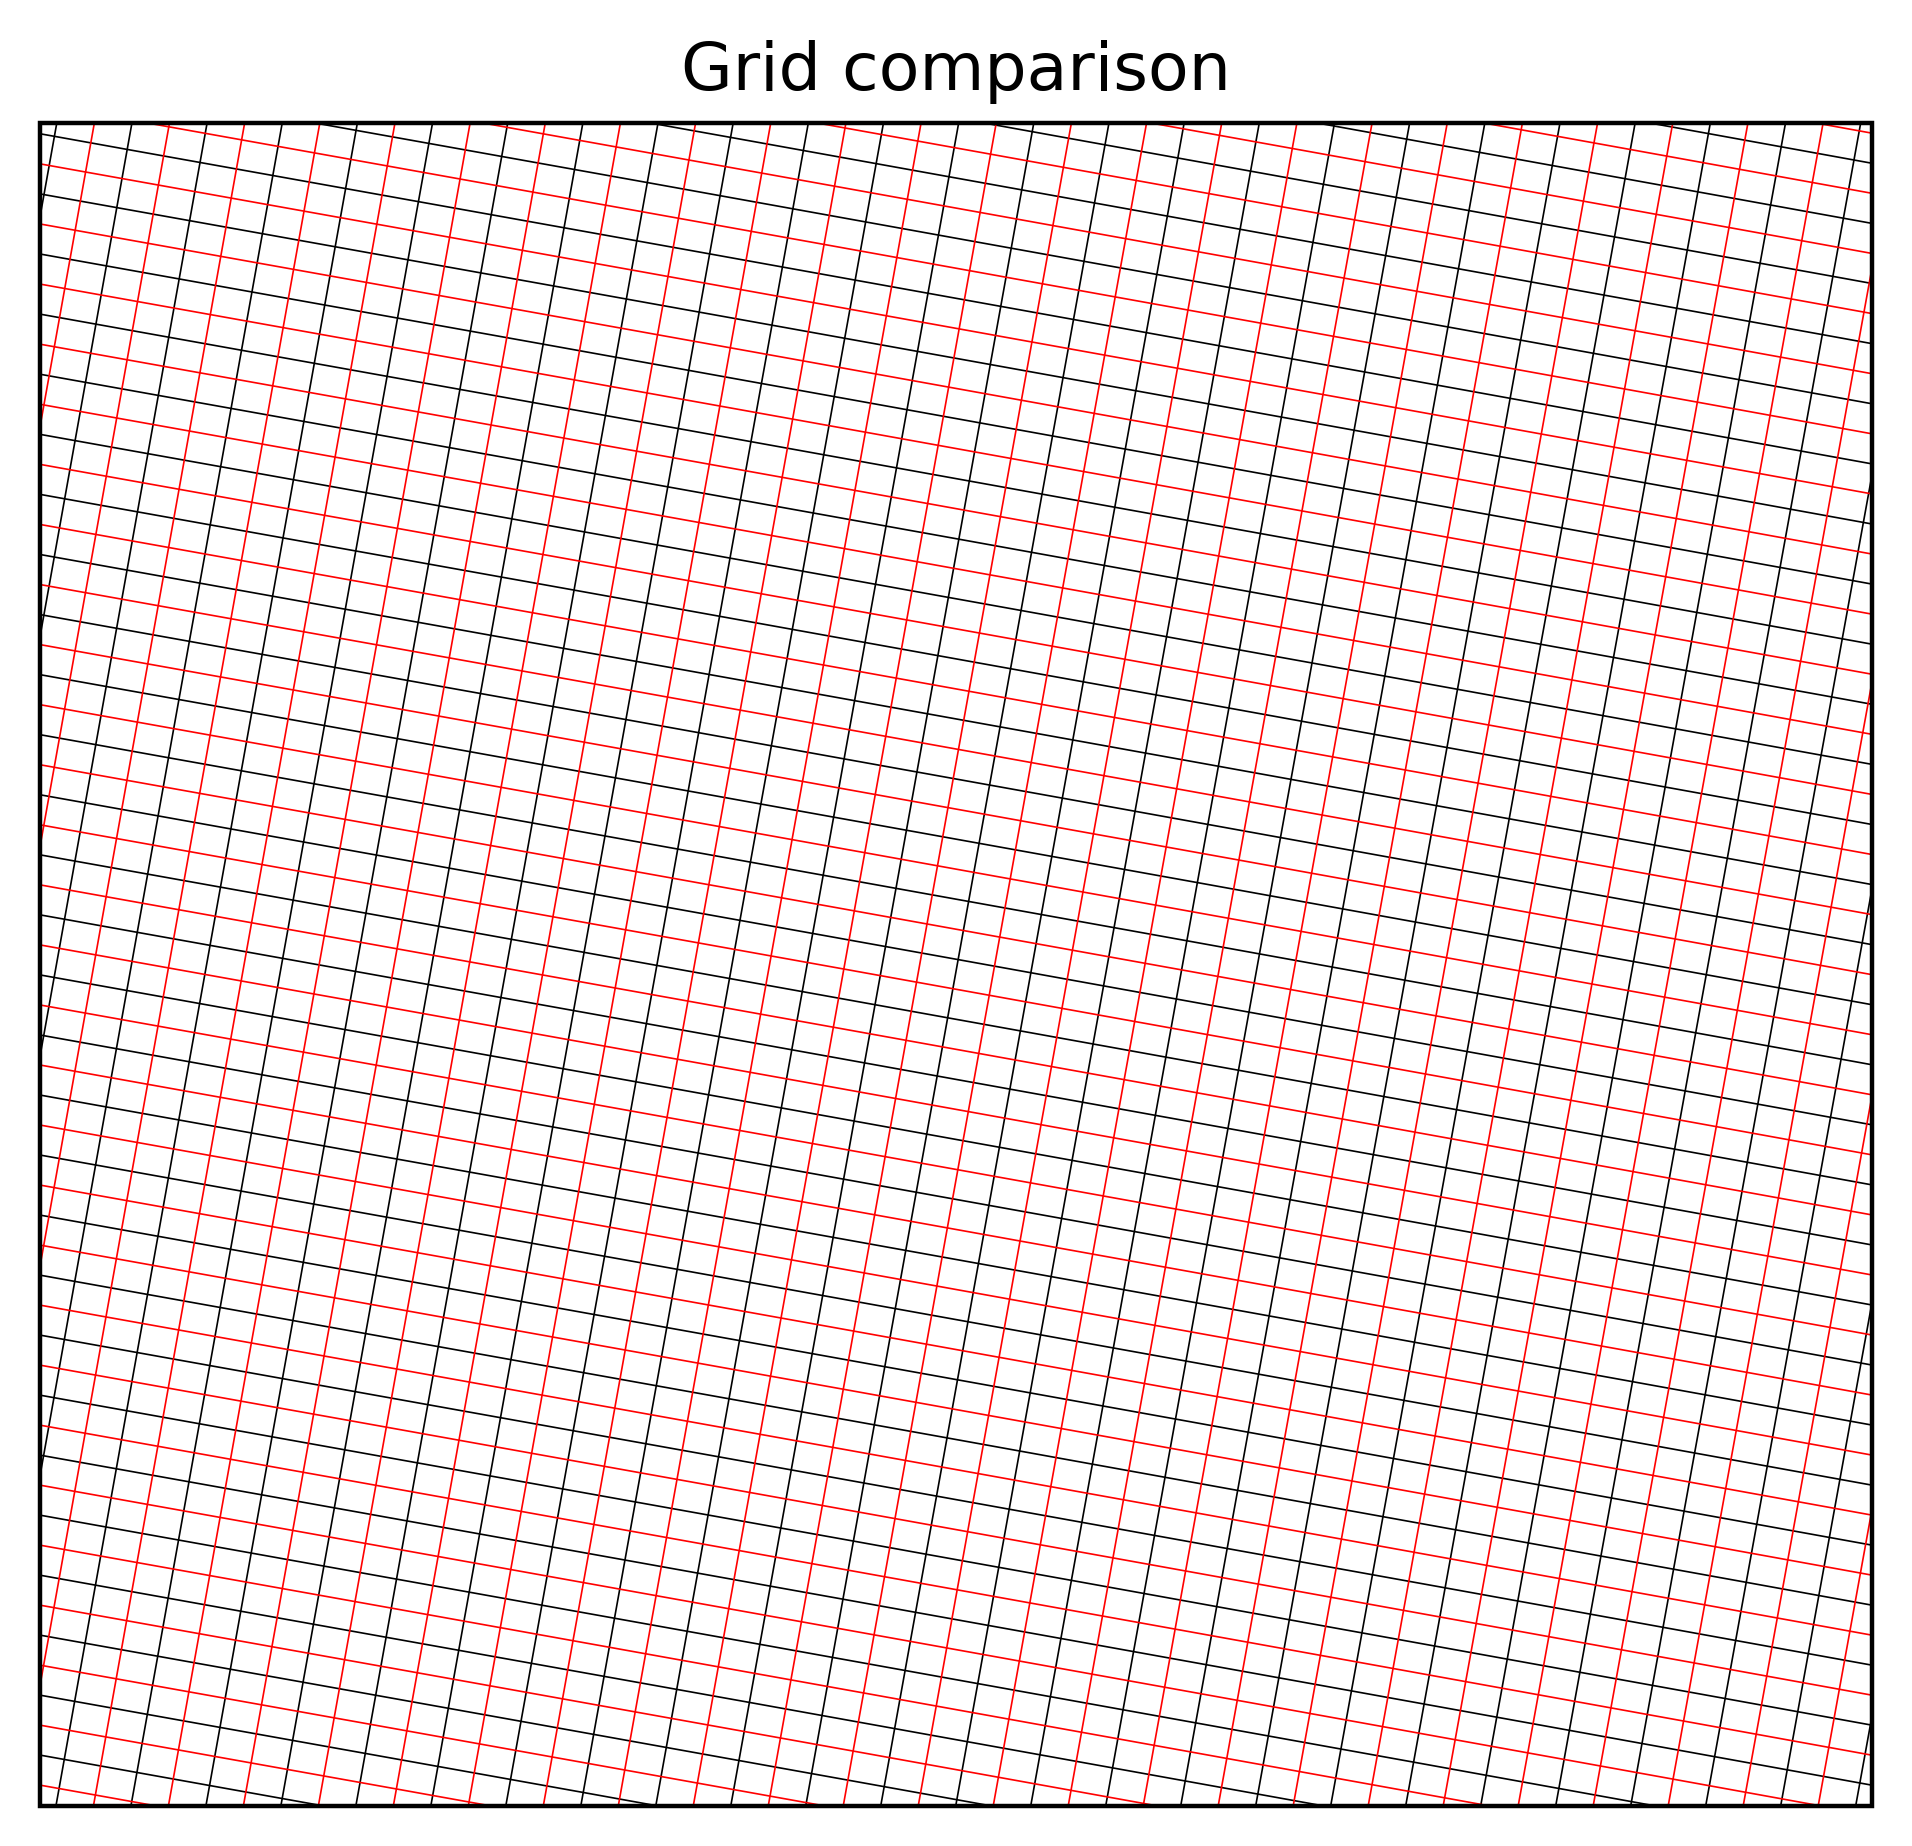

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4.5), dpi=400,
                       constrained_layout=True, subplot_kw={'projection': crs})

# Set extent and map features
ax.set_extent([-147.5,-147, 70.85, 71],ccrs.PlateCarree())
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                            facecolor='0.8'), linewidth=.7)
ax.coastlines(resolution='10m', linewidth=.7)
ax.add_feature(rivers, linewidth=0.75, edgecolor='tab:blue')
ax.add_feature(cartopy.feature.RIVERS, linewidth=0.75, color='tab:blue')

ulon = dsc.ulon
ulat = dsc.ulat

# Plot lines in the x-direction (constant j, vary i)
for j in range(ulat.shape[0]):
    ax.plot(ulon[j, :], ulat[j, :], color='black', linewidth=0.3, transform=ccrs.PlateCarree())

# Plot lines in the y-direction (constant i, vary j)
for i in range(ulat.shape[1]):
    ax.plot(ulon[:, i], ulat[:, i], color='black', linewidth=0.3, transform=ccrs.PlateCarree())

ulon = dsr.lon_rho 
ulat = dsr.lat_rho 

# Plot lines in the x-direction (constant j, vary i)
for j in range(ulat.shape[0]):
    ax.plot(ulon[j, :], ulat[j, :], color='red', linewidth=0.3, transform=ccrs.PlateCarree())

# Plot lines in the y-direction (constant i, vary j)
for i in range(ulat.shape[1]):
    ax.plot(ulon[:, i], ulat[:, i], color='red', linewidth=0.3, transform=ccrs.PlateCarree())

ax.set_title('Grid comparison')

fig.canvas.draw()